In [1]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt
import glob
from tqdm.auto import tqdm
from pathlib import Path
from IPython.display import clear_output
import numpy as np
from PIL import ImageOps

model = YOLO("C:\\Users\\User\\Python\\ML\\Deep Learning\\runs\\detect\\experiments\\license_platev1\\run_1\\weights\\best.pt")
#data_path = "C:\\Users\\User\\OneDrive\\Masaüstü\\OCR\\downloaded-plates"
data_path = "C:\\Users\\User\\OneDrive\\Masaüstü\\OCR\\test-plates"
all_images = glob.glob(os.path.join(data_path, "**", "*.jpg"), recursive=True)

print(f"Found {len(all_images)} images...")

Found 10 images...


In [2]:
folder_path = "C:\\Users\\User\\Python\\ML\\Deep Learning\\test_plate_data"
Path(folder_path).mkdir(parents=True,exist_ok=True)


saved_idx = 0

all_images=  all_images[saved_idx:]

for idx, img in tqdm(enumerate(all_images)):
    results = model(img)
    
    if len(results[0].boxes) == 0:
        print("No plate detected, skipping...")
        continue
    if len(results[0].boxes) > 1:
        print("Found multiple plates, skipping...")
        continue
        
    annotated_frame = results[0].plot()
    plt.figure(figsize=(15,15))
    plt.imshow(annotated_frame)
    plt.show()
    
    plate_number = input("PLATE_NO (q to quit, s to skip): ")
    
    if plate_number.lower() == "q":
        np.save("last_idx_pt2.npy", np.array(idx + saved_idx))
        print(f"Progress saved at index {idx + saved_idx}")
        break
    elif plate_number.lower() == "s":
        np.save("last_idx_pt2.npy", np.array(idx + saved_idx))
        continue
    else:
        x1, y1, x2, y2 = results[0].boxes.xyxy[0].int().tolist()
        img_pil = ImageOps.exif_transpose(Image.open(img))  # fixes rotation from EXIF
        img_np = np.array(img_pil)
        crop = img_np[y1:y2, x1:x2]    # y first, x second
        crop = Image.fromarray(crop).convert('RGB')
        crop.save(os.path.join(folder_path, f"{idx + saved_idx}_{plate_number}.jpg"))
        print(f"Saved: {idx + saved_idx}_{plate_number}.jpg")
        np.save("last_idx_pt2.npy", np.array(idx + saved_idx))
        clear_output()


image 1/1 C:\Users\User\OneDrive\Masast\Turkish Car Downloaded\026ac31e-3134-459a-83b9-260752071a8a_image_for_silan_41642164_580x435.jpg: 480x640 1 license_plate, 121.3ms
Speed: 5.9ms preprocess, 121.3ms inference, 6.9ms postprocess per image at shape (1, 3, 480, 640)


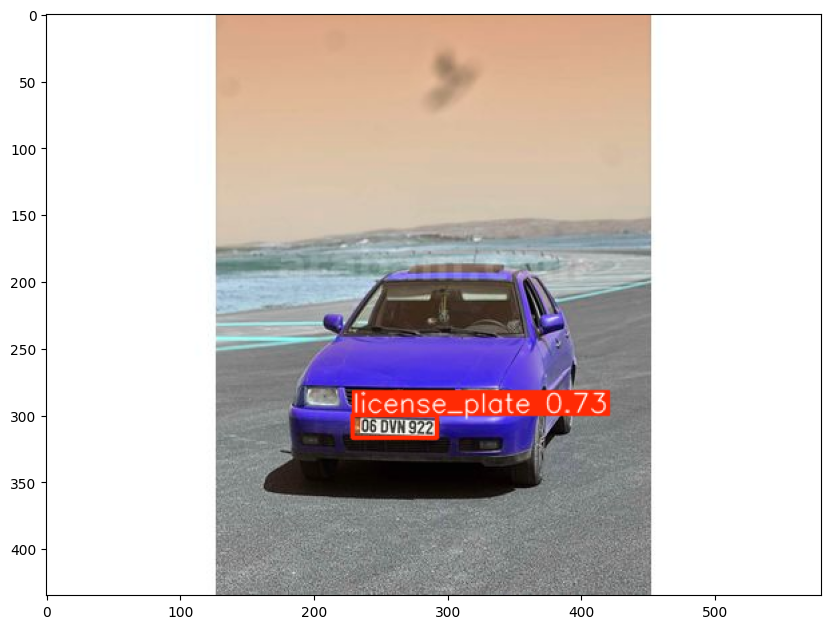

In [103]:
ex_img = all_images[2]
results = model(ex_img)
annotated_frame = results[0].plot()
plt.figure(figsize=(10,10))
plt.imshow(annotated_frame)
plt.show()

In [104]:
x1,y1,x2,y2 = results[0].boxes.xyxy[0].int().tolist()
x1,y1,x2,y2

(229, 300, 292, 317)

ValueError: zero-size array to reduction operation minimum which has no identity

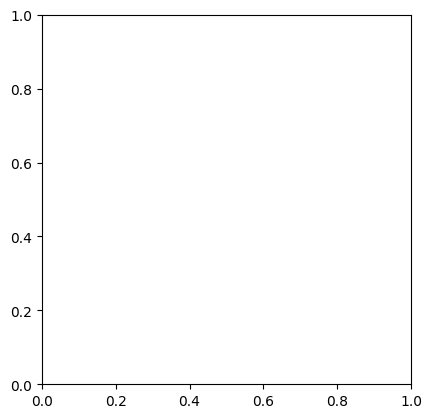

In [108]:
ex_img_op = Image.open(ex_img).rotate(0).resize((64,256))
ex_img_final = np.array(ex_img_op)
ex_img_f2 = ex_img_final[y1:y2,x1:x2]

plt.imshow(ex_img_f2)

In [107]:
ex_img_f2.shape

(17, 63, 3)

In [56]:
img = Image.fromarray(img)

In [59]:
img.save("extracted_plate.jpg")